## Part B :Data Acquisiton

## 1. Import Libraries

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import sqlite3
import requests
import sweetviz as sv

## 2. Load CSV

In [14]:
df = pd.read_csv("customer_data.csv")
print(df.head())

   Customer_ID   Name   Age  Gender       City   Income  Purchases Membership  \
0          101   Amit  25.0    Male  Ahmedabad  35000.0          5     Silver   
1          102  Priya  30.0  Female      Surat  45000.0          7       Gold   
2          103  Rahul  35.0    Male     Rajkot  55000.0          9       Gold   
3          104  Sneha   NaN  Female   Vadodara  40000.0          6     Silver   
4          105  Karan  40.0    Male  Ahmedabad  65000.0         10   Platinum   

  Churn  
0    No  
1    No  
2   Yes  
3    No  
4   Yes  


## 3. Load JSON

In [15]:
json_df = pd.read_json("customer.json")
print(json_df)

    Customer_ID    Name   Age  Gender       City   Income  Purchases  \
0           101    Amit  25.0    Male  Ahmedabad  35000.0          5   
1           102   Priya  30.0  Female      Surat  45000.0          7   
2           103   Rahul  35.0    Male     Rajkot  55000.0          9   
3           104   Sneha   NaN  Female   Vadodara  40000.0          6   
4           105   Karan  40.0    Male  Ahmedabad  65000.0         10   
5           106   Divya  28.0  Female      Surat      NaN          4   
6           107   Rohan  32.0    Male     Rajkot  50000.0          8   
7           108  Anjali  29.0  Female   Vadodara  42000.0          5   
8           109   Vikas  45.0    Male  Ahmedabad  80000.0         12   
9           110    Neha  27.0  Female      Surat  38000.0          4   
10          111   Arjun  31.0    Male     Rajkot  52000.0          8   
11          112   Pooja  26.0  Female   Vadodara  39000.0          5   
12          113    Yash  38.0    Male  Ahmedabad  62000.0       

## 4. Load SQL Table 

In [16]:
conn = sqlite3.connect("customers.db")
df.to_sql("customers", conn, if_exists="replace", index=False)
sql_df = pd.read_sql("SELECT * FROM customers", conn)
print(sql_df.head())
conn.close()

   Customer_ID   Name   Age  Gender       City   Income  Purchases Membership  \
0          101   Amit  25.0    Male  Ahmedabad  35000.0          5     Silver   
1          102  Priya  30.0  Female      Surat  45000.0          7       Gold   
2          103  Rahul  35.0    Male     Rajkot  55000.0          9       Gold   
3          104  Sneha   NaN  Female   Vadodara  40000.0          6     Silver   
4          105  Karan  40.0    Male  Ahmedabad  65000.0         10   Platinum   

  Churn  
0    No  
1    No  
2   Yes  
3    No  
4   Yes  


## 5. Load API

In [17]:
url = "https://jsonplaceholder.typicode.com/users"
response = requests.get(url)
api_data = response.json()
api_df = pd.DataFrame(api_data)
print(api_df.head())

   id              name   username                      email  \
0   1     Leanne Graham       Bret          Sincere@april.biz   
1   2      Ervin Howell  Antonette          Shanna@melissa.tv   
2   3  Clementine Bauch   Samantha         Nathan@yesenia.net   
3   4  Patricia Lebsack   Karianne  Julianne.OConner@kory.org   
4   5  Chelsey Dietrich     Kamren   Lucio_Hettinger@annie.ca   

                                             address                  phone  \
0  {'street': 'Kulas Light', 'suite': 'Apt. 556',...  1-770-736-8031 x56442   
1  {'street': 'Victor Plains', 'suite': 'Suite 87...    010-692-6593 x09125   
2  {'street': 'Douglas Extension', 'suite': 'Suit...         1-463-123-4447   
3  {'street': 'Hoeger Mall', 'suite': 'Apt. 692',...      493-170-9623 x156   
4  {'street': 'Skiles Walks', 'suite': 'Suite 351...          (254)954-1289   

         website                                            company  
0  hildegard.org  {'name': 'Romaguera-Crona', 'catchPhrase': 'Mu

## Part C: Data Understanding & Cleaning

## 6. Perform initial exploration:

## A. head(), info(), describe()

In [18]:
## head()

print("================ Head ==================")
print(df.head())

## info()

print("================ Info ==================")
print(df.info())

## describe()

print("================ Describe ==================")
print(df.describe())

================ Head ==================
   Customer_ID   Name   Age  Gender       City   Income  Purchases Membership  \
0          101   Amit  25.0    Male  Ahmedabad  35000.0          5     Silver   
1          102  Priya  30.0  Female      Surat  45000.0          7       Gold   
2          103  Rahul  35.0    Male     Rajkot  55000.0          9       Gold   
3          104  Sneha   NaN  Female   Vadodara  40000.0          6     Silver   
4          105  Karan  40.0    Male  Ahmedabad  65000.0         10   Platinum   

  Churn  
0    No  
1    No  
2   Yes  
3    No  
4   Yes  
================ Info ==================
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Customer_ID  20 non-null     int64  
 1   Name         20 non-null     str    
 2   Age          19 non-null     float64
 3   Gender       20 non-null     str    
 4   City         20 non-nul

## B. Missing values & Duplicate Rows


In [19]:
## Missing values 

print("=================== Missing values ===================")
print(df.isnull().sum())

## Duplicate Rows

print("=================== Duplicate Rows =====================")
print(df.duplicated().sum())


=================== Missing values ===================
Customer_ID    0
Name           0
Age            1
Gender         0
City           0
Income         1
Purchases      0
Membership     0
Churn          0
dtype: int64
=================== Duplicate Rows =====================
0


## 7. Apply data cleaning 

## A. Handle missing data

In [20]:
## Handle Missing data 

df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Income"] = df["Income"].fillna(df["Income"].mean())

## B. Data Types


In [21]:
print(df.dtypes)

Customer_ID      int64
Name               str
Age            float64
Gender             str
City               str
Income         float64
Purchases        int64
Membership         str
Churn              str
dtype: object


## C. Remove Irrelevant Column

In [22]:
df = df.drop(columns=["Customer_ID"])

## Part D: Exploratory Data Analysis (EDA)

## 8. Univariate Analysis

## A. Age Distribution plots 

======================= Age Distribution =======================


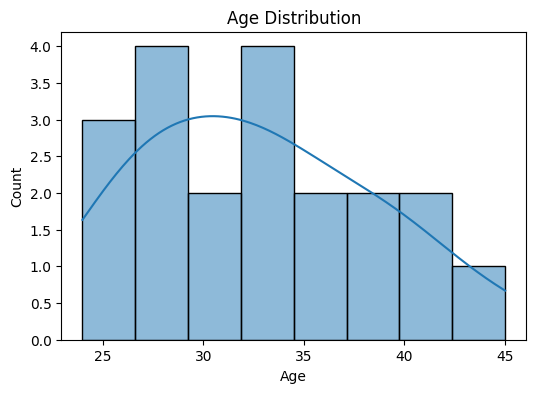

======================= Income Distribution =======================


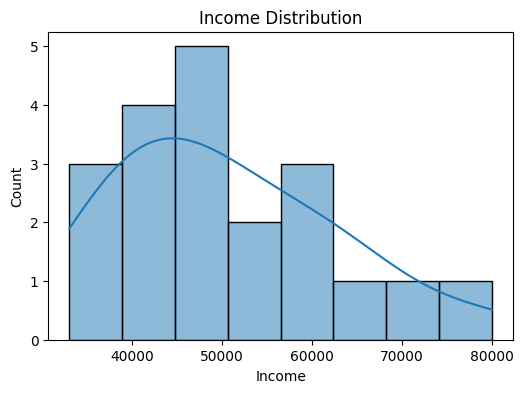

======================= Purchases Distribution =======================


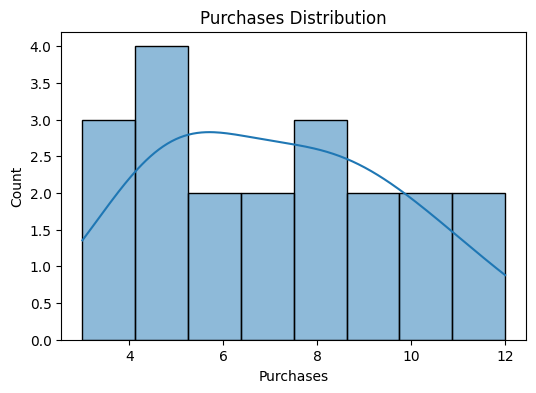

In [25]:
print("======================= Age Distribution =======================")
plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=8, kde=True)
plt.title("Age Distribution")
plt.show()

##Income Distribution

print("======================= Income Distribution =======================")
plt.figure(figsize=(6,4))
sns.histplot(df["Income"], bins=8, kde=True)
plt.title("Income Distribution")
plt.show()

##Purchases Distribution
print("======================= Purchases Distribution =======================")
plt.figure(figsize=(6,4))
sns.histplot(df["Purchases"], bins=8, kde=True)
plt.title("Purchases Distribution")
plt.show()

## B. Bivariate Analysis

======================= Gender vs Purchases =======================


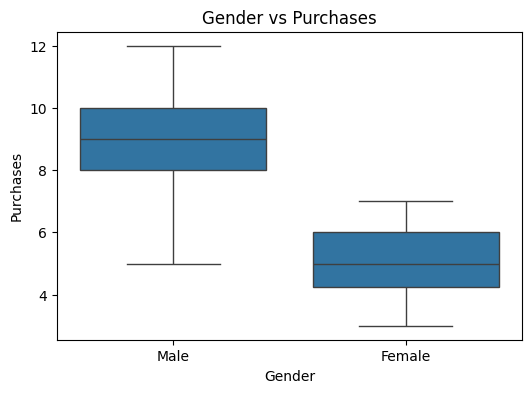

======================= Income vs Churn =======================


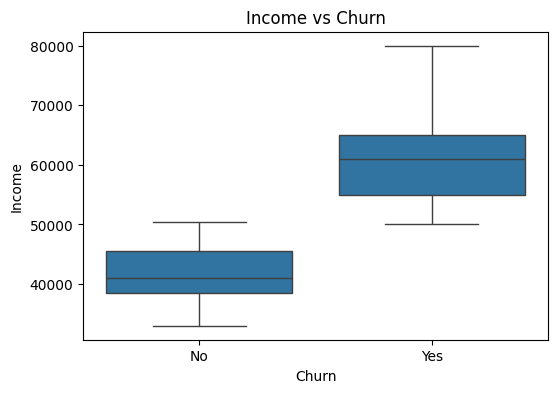

In [27]:
## Gender vs Purchases 
print("======================= Gender vs Purchases =======================")
plt.figure(figsize=(6,4))
sns.boxplot(x="Gender", y="Purchases", data=df)
plt.title("Gender vs Purchases")
plt.show()

## Income vs Churn 
print("======================= Income vs Churn =======================")
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="Income", data=df)
plt.title("Income vs Churn")
plt.show()


## 10. Multivariate Analysis 

======================= Correlation Heatmap =======================


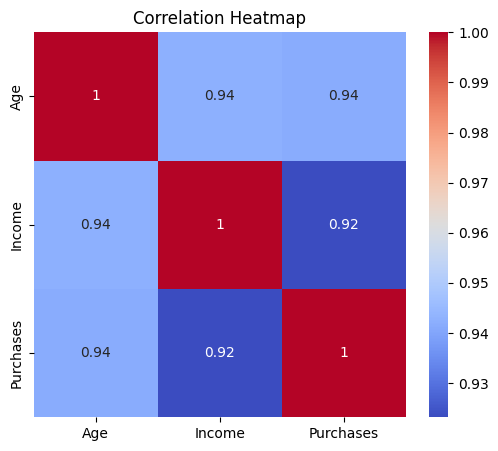

======================= Pair Plot =======================


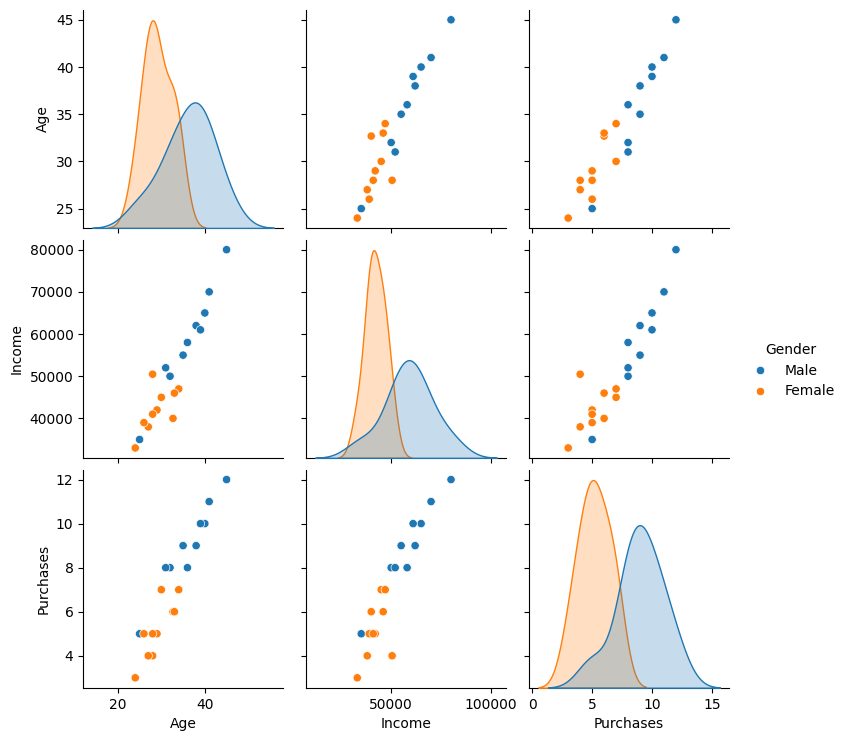

In [29]:
##  Correlation Heatmap
print("======================= Correlation Heatmap =======================")
plt.figure(figsize=(6,5))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Pair Plot
print("======================= Pair Plot =======================")
sns.pairplot(df, hue="Gender")
plt.show()

## Part E : Data Profiling 

In [31]:
report = sv.analyze(df, target_feat="Churn")
report.show_html("Customer_Sweetviz_Report.html")

                                             |          | [  0%]   00:00 -> (? left)

Report Customer_Sweetviz_Report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
